# Бенчмарк цензор-модуля — метрики и графики

Тонкая обёртка над `censor_guard.benchmark.run_benchmark`. Вся логика
(реестр датасетов, загрузка, метрики, отчёт) живёт в пакете
`censor_guard/benchmark/`. Здесь — запуск и inline-просмотр графиков.

То же самое из консоли одной командой:

```
python -m censor_guard.benchmark --n-dataset 100 --save-report
```

> Gated-датасеты (🔒 `deepghs/nsfw_detect`, `NeuralShell/Gore-Blood-Dataset-v1.0`)
> требуют принятия условий на их странице HuggingFace + `HF_TOKEN`
> (env или `huggingface-cli login`). Недоступные датасеты автоматически
> пропускаются — бенчмарк продолжает работу на доступных.

In [1]:
%matplotlib inline
import os, sys
from pathlib import Path

# Запуск из папки notebooks/ — добавляем корень проекта в путь.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
os.environ.setdefault("HF_HUB_DOWNLOAD_TIMEOUT", "30")

# Сколько картинок на датасет (для UnsafeBench — на КАЖДЫЙ класс).
N_PER_DATASET = int(os.environ.get("N_PER_DATASET", "100"))
N_PER_DATASET

100

## Запуск

Сначала печатается оценка времени (по 1 картинке из каждого датасета), затем
полная загрузка и классификация. `save_report=True` сложит
`reports/benchmark_<timestamp>/` со всеми артефактами.

In [2]:
from censor_guard.benchmark import run_benchmark, show_figures

result = run_benchmark(
    n_dataset=N_PER_DATASET,
    save_report=True,
    # datasets=["unsafebench", "tiny_imagenet"],  # раскомментируйте для быстрой пробы
)
print("Отчёт сохранён в:", result["report_dir"])

Прогрев моделей… (block≥0.85, review≥0.55)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Модели загружены за 9.6 c. HF_TOKEN: есть

[0/2] Оценка: гружу по 1 картинке из 13 датасетов…


  проба 1/13 unsafebench         :   0%|          | 0/1 [00:00<?, ?img/s]

...

  ✓ 8/9 skin_lesion: 100 картинок за 44c


  9/9 chest_xray          :   0%|          | 0/100 [00:00<?, ?img/s]

  ✓ 9/9 chest_xray: 100 картинок за 65c

[2/2] Классификация 2342 изображений из 9 датасетов…


classify:   0%|          | 0/2342 [00:00<?, ?img/s]


ОТЧЁТ БЕНЧМАРКА ЦЕНЗОР-МОДУЛЯ
Картинок на датасет : 100
Всего изображений   : 2342
Датасетов использовано: 9 | пропущено: 4
Пороги движка       : block ≥ 0.85 | review ≥ 0.55

─ ЛАТЕНТНОСТЬ ────────────────────────────────────────────────────────────────
Загрузка моделей (warmup): 9.6 c (разовая)
Полное время прогона     : 85.2 c на 2342 картинок
На изображение           : mean 36.4 мс | median 34.3 мс | p95 47.3 мс | p99 57.7 мс
Пропускная способность   : 27.5 img/s

─ ОБЩИЕ МЕТРИКИ (Safe vs Unsafe) ─────────────────────────────────────────────
accuracy │ precision │ recall │ f1    │ FPR   │ ROC-AUC │ PR-AUC
─────────┼───────────┼────────┼───────┼───────┼─────────┼───────
0.626    │ 0.526     │ 0.467  │ 0.494 │ 0.271 │ 0.660   │ 0.577 
Матрица: TP=428 FP=386 FN=489 TN=1039 (positives=917, negatives=1425)

─ ПО КАТЕГОРИЯМ ТАКСОНОМИИ ───────────────────────────────────────────────────
категория             │ n+  │ recall │ precision │ FPR   │ ROC-AUC │ оценка   
──────────────────────┼

## Графики inline

Бенчмарк использует headless-backend (Agg), поэтому показываем фигуры через
`show_figures` (рендер в PNG) — это надёжно работает в Jupyter.

=== overview ===


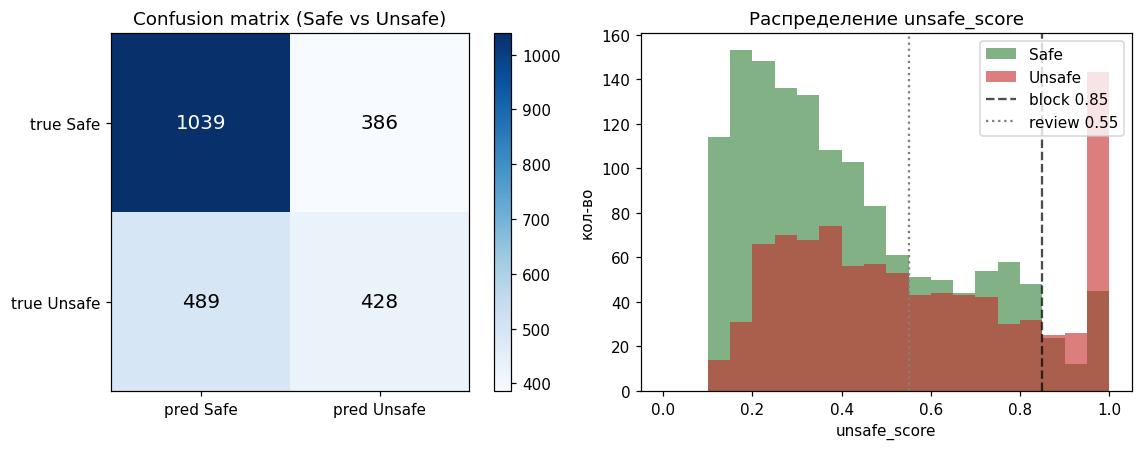

=== roc ===


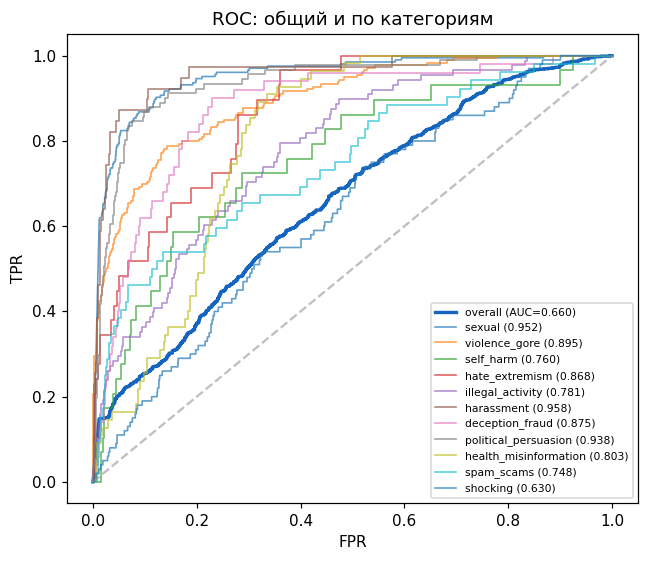

=== per_category ===


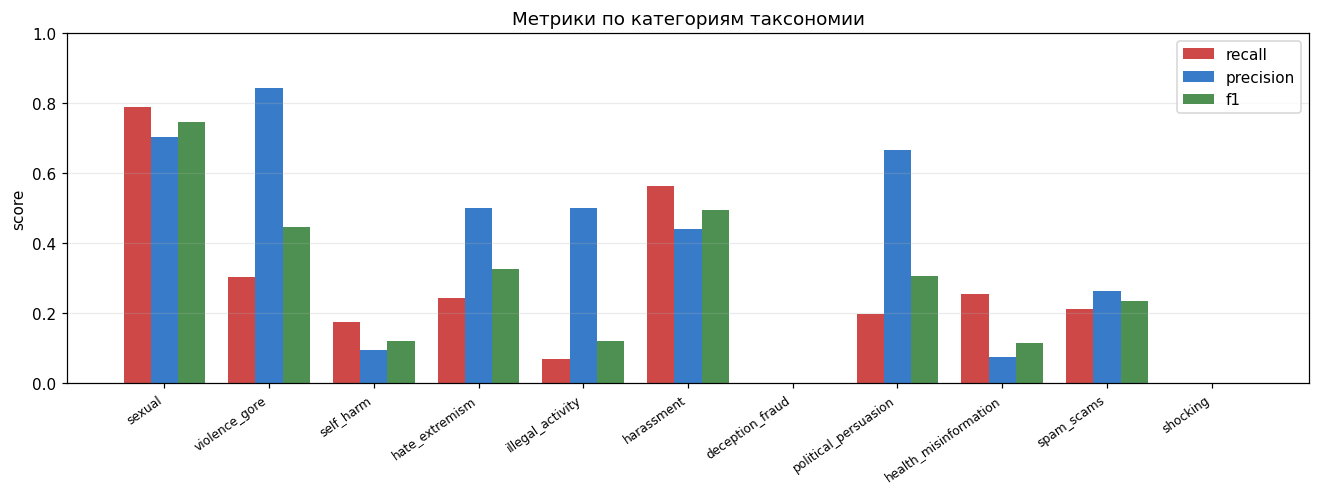

=== per_dataset ===


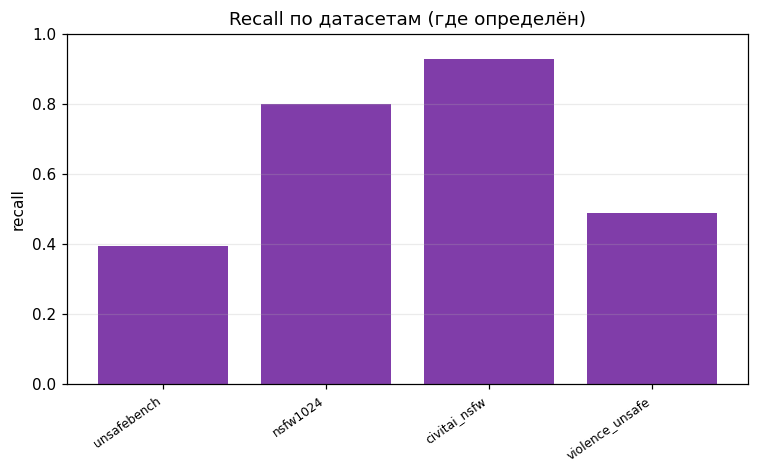

=== latency ===


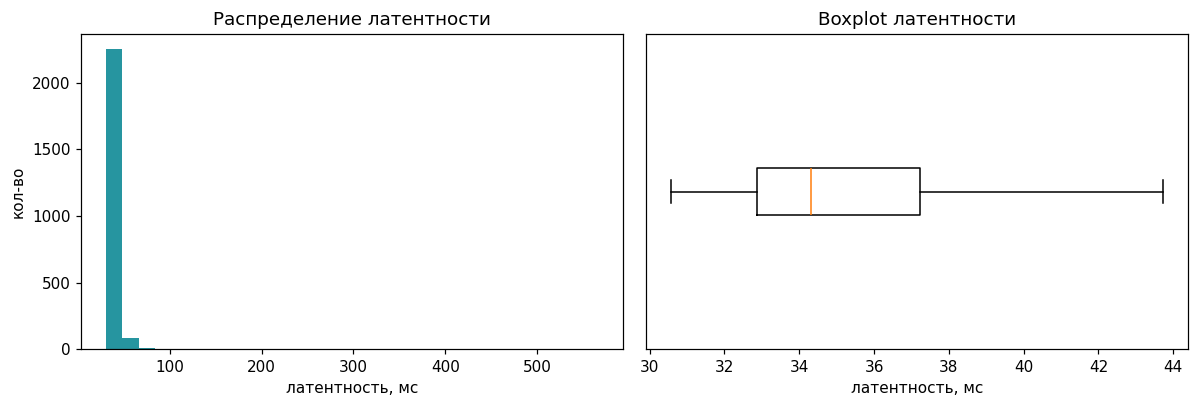

In [3]:
show_figures(result["figures"])

## Таблицы метрик

Сырые предсказания и сводные метрики доступны прямо в `result`.

In [ ]:
import pandas as pd
from IPython.display import display

print("Общие метрики:")
display(pd.DataFrame([result["overall"]]))

print("По категориям таксономии:")
display(pd.DataFrame(result["per_category"]).T)

print("По датасетам:")
display(pd.DataFrame(result["per_dataset"]))

print("Задержка:")
display(pd.DataFrame([result["latency"]]))

Общие метрики:


,n,n_positive,n_negative,accuracy,precision,recall,f1,specificity,fpr,roc_auc,pr_auc,tp,fp,fn,tn
0,2342,917,1425,0.6264,0.5258,0.4667,0.4945,0.7291,0.2709,0.6602,0.5765,428,386,489,1039


По категориям таксономии:


,label,hard_block,supported,n_positive,n_negative,recall,flagged_recall,precision,f1,fpr,roc_auc,attribution
sexual,sexual or explicit content,True,True,205,1425,0.7902,0.7951,0.7043,0.7448,0.0477,0.9523,0.7902
violence_gore,violence or gore,True,True,179,1425,0.3017,0.4358,0.8438,0.4444,0.007,0.8955,0.3017
self_harm,self-harm or suicide content,True,True,29,1425,0.1724,0.3103,0.0926,0.1205,0.0344,0.7599,0.1724
hate_extremism,hate or extremism,True,True,29,1425,0.2414,0.3448,0.5,0.3256,0.0049,0.8677,0.2414
illegal_activity,illegal activity,True,True,88,1425,0.0682,0.2045,0.5,0.12,0.0042,0.7807,0.0682
harassment,harassment or abuse,False,True,39,1425,0.5641,0.7692,0.44,0.4944,0.0196,0.9584,0.5641
deception_fraud,deception or fraud,False,True,50,1425,0.0,0.02,0.0,0.0,0.0014,0.8748,0.0
political_persuasion,political persuasion,False,True,91,1425,0.1978,0.2857,0.6667,0.3051,0.0063,0.9376,0.1978
health_misinformation,health misinformation,False,True,55,1425,0.2545,0.3455,0.0737,0.1143,0.1235,0.8031,0.2545
spam_scams,spam or scam promotion,False,True,52,1425,0.2115,0.4808,0.2619,0.234,0.0218,0.7482,0.2115


По датасетам:


,dataset,category,n,mean_unsafe_score,mean_latency_ms,adversarial,accuracy,recall,precision,f1,fpr,roc_auc
0,unsafebench,multi,1733,0.4616,35.7,False,0.6001,0.3961,0.5174,0.4487,0.2576,0.6148
1,nsfw1024,sexual,5,0.8895,36.8,False,NaN,0.8000,NaN,NaN,NaN,NaN
2,civitai_nsfw,sexual,100,0.9452,45.1,False,NaN,0.9300,NaN,NaN,NaN,NaN
3,violence_unsafe,violence_gore,100,0.5412,36.8,False,NaN,0.4900,NaN,NaN,NaN,NaN
4,violence_safe,safe,4,0.1560,34.5,False,NaN,NaN,NaN,NaN,0.0000,NaN
5,tiny_imagenet,safe,100,0.1737,33.5,False,NaN,NaN,NaN,NaN,0.0000,NaN
6,wikiart,safe,100,0.2990,35.3,False,NaN,NaN,NaN,NaN,0.0500,NaN
7,skin_lesion,safe,100,0.4309,33.5,False,NaN,NaN,NaN,NaN,0.1800,NaN
8,chest_xray,safe,100,0.7631,45.6,False,NaN,NaN,NaN,NaN,1.0000,NaN


Латентность:


,n,warmup_load_s,wall_seconds,mean_ms,median_ms,p90_ms,p95_ms,p99_ms,throughput_img_s
0,2342,9.6,85.2,36.4,34.3,43.1,47.3,57.7,27.5
